<p style="align: center;"><img align=center src="https://drive.google.com/uc?export=view&id=1TRNaCfYstvcIQqoUSdukYQGF6LuyL7Tv" width=600 height=320/></p>
<h3 style="text-align: center;"><b>Школа глубокого обучения ФПМИ МФТИ</b></h3>

# Домашнее задание. Автоэнкодеры


# Часть 1. Vanilla Autoencoder (10 баллов)

## 1.1. Подготовка данных (1 балл)


In [1]:
import numpy as np
from torch.autograd import Variable
from torchvision import datasets
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.utils.data as data_utils
import torch
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
import os
import pandas as pd
import skimage.io
from skimage.transform import resize
from torchvision import transforms

%matplotlib inline

In [168]:
def fetch_dataset(attrs_name = "lfw_attributes.txt",
                      images_name = "lfw-deepfunneled",
                      dx=80,dy=80,
                      dimx=64,dimy=64
    ):

    #download if not exists
    if not os.path.exists(images_name):
        print("images not found, donwloading...")
        os.system("wget http://vis-www.cs.umass.edu/lfw/lfw-deepfunneled.tgz -O tmp.tgz")
        print("extracting...")
        os.system("tar xvzf tmp.tgz && rm tmp.tgz")
        print("done")
        assert os.path.exists(images_name)

    if not os.path.exists(attrs_name):
        print("attributes not found, downloading...")
        os.system("wget http://www.cs.columbia.edu/CAVE/databases/pubfig/download/%s" % attrs_name)
        print("done")

    #read attrs
    df_attrs = pd.read_csv("lfw_attributes.txt",sep='\t',skiprows=1,)
    df_attrs = pd.DataFrame(df_attrs.iloc[:,:-1].values, columns = df_attrs.columns[1:])


    #read photos
    photo_ids = []
    for dirpath, dirnames, filenames in os.walk(images_name):
        for fname in filenames:
            if fname.endswith(".jpg"):
                fpath = os.path.join(dirpath,fname)
                photo_id = fname[:-4].replace('_',' ').split()
                person_id = ' '.join(photo_id[:-1])
                photo_number = int(photo_id[-1])
                photo_ids.append({'person':person_id,'imagenum':photo_number,'photo_path':fpath})

    photo_ids = pd.DataFrame(photo_ids)
    # print(photo_ids)
    #mass-merge
    #(photos now have same order as attributes)
    df = pd.merge(df_attrs,photo_ids,on=('person','imagenum'))

    assert len(df)==len(df_attrs),"lost some data when merging dataframes"

    # print(df.shape)
    #image preprocessing
    all_photos =df['photo_path'].apply(skimage.io.imread)\
                                .apply(lambda img:img[dy:-dy,dx:-dx])\
                                .apply(lambda img: resize(img,[dimx,dimy]))

    all_photos = np.stack(all_photos.values)#.astype('uint8')
    all_attrs = df.drop(["photo_path","person","imagenum"],axis=1)

    return all_photos, all_attrs

In [169]:
# The following line fetches you two datasets: images, usable for autoencoder training and attributes.
# Those attributes will be required for the final part of the assignment (applying smiles), so please keep them in mind


data, attrs = fetch_dataset()


Разбейте выборку картинок на train и val, выведите несколько картинок в output, чтобы посмотреть, как они выглядят, и приведите картинки к тензорам pytorch, чтобы можно было скормить их сети:

In [217]:
from sklearn.model_selection import train_test_split
train_photos, val_photos, train_attrs, val_attrs = train_test_split(data, attrs, train_size=0.9, shuffle=False)


Вывод картинок

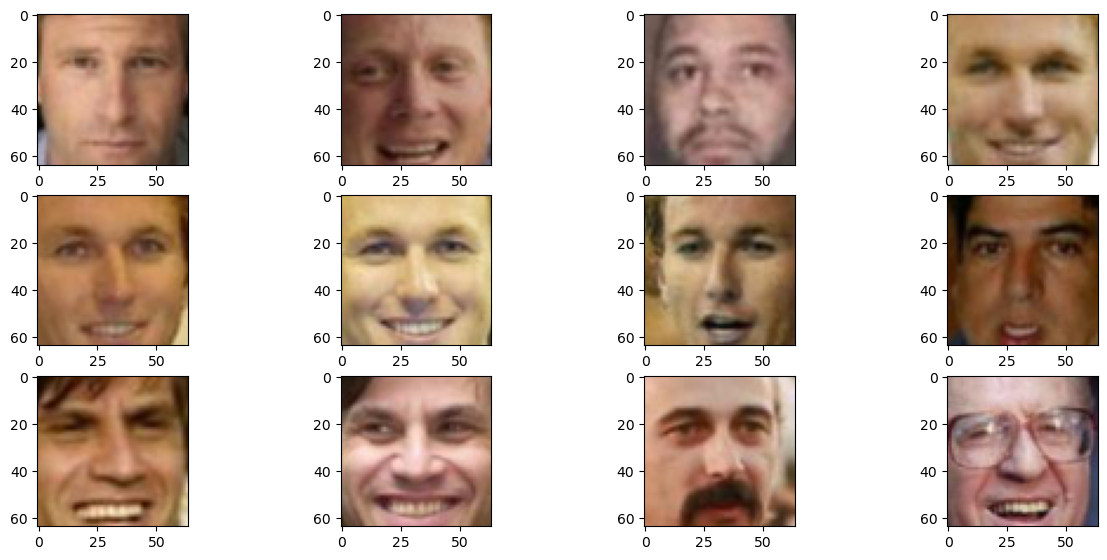

In [171]:
plt.figure(figsize=(15, 9))
for i  in range(12):
    plt.subplot(4, 4, i + 1)
    plt.imshow(train_photos[i])

In [218]:
train_photos = torch.FloatTensor(train_photos).permute(0, 3, 1, 2)
val_photos = torch.FloatTensor(val_photos).permute(0, 3, 1, 2)
train_loader = torch.utils.data.DataLoader(train_photos, batch_size=32)
val_loader = torch.utils.data.DataLoader(val_photos, batch_size=32)

## 1.2. Архитектура модели (2 балла)
В этом разделе мы напишем и обучем обычный автоэнкодер.



<img src="https://www.notion.so/image/https%3A%2F%2Fs3-us-west-2.amazonaws.com%2Fsecure.notion-static.com%2F4b8adf79-8e6a-4b7d-9061-8617a00edbb1%2F__2021-04-30__14.53.33.png?table=block&id=56f187b4-279f-4208-b1ed-4bda5f91bfc0&width=2880&userId=3b1b5e32-1cfb-4b0f-8705-5a524a8f56e3&cache=v2" alt="Autoencoder">


^ напомню, что автоэнкодер выглядит вот так

In [173]:
dim_code = 256 # выберите размер латентного вектора

Реализуем autoencoder. Архитектуру (conv, fully-connected, ReLu, etc) можете выбирать сами. Экспериментируйте!

In [174]:
from copy import deepcopy

class Autoencoder(nn.Module):
    def __init__(self):
        super(Autoencoder, self).__init__()

        self.encoder = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(in_channels=128, out_channels=dim_code, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(dim_code),
            nn.ReLU(),
            nn.Flatten(),
            nn.Linear(4096, dim_code)

        )

        self.decoder = nn.Sequential(
            nn.Linear(dim_code, 4096),
            nn.Unflatten(dim=1, unflattened_size=(256, 4, 4)),
            nn.ConvTranspose2d(in_channels=dim_code, out_channels=128, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.ConvTranspose2d(in_channels=128, out_channels=64, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.ConvTranspose2d(in_channels=64, out_channels=32, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.ConvTranspose2d(in_channels=32, out_channels=3, kernel_size=3, stride=2, padding=1, output_padding=1),
        )

    def forward(self, sample):
        latent_code = self.encoder(sample)
        reconstruction = self.decoder(latent_code)
        return reconstruction, latent_code
    def sample(self, sample):
        reconstruction = self.decoder(sample)
        return reconstruction

In [175]:
device = 'cuda:0' if torch.cuda.is_available() else 'cpu'

criterion = F.mse_loss

model = Autoencoder().to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

## 1.3 Обучение (2 балла)

Осталось написать код обучения автоэнкодера. При этом было бы неплохо в процессе иногда смотреть, как автоэнкодер реконструирует изображения на данном этапе обучения. Наример, после каждой эпохи (прогона train выборки через автоэекодер) можно смотреть, какие реконструкции получились для каких-то изображений val выборки.

А, ну еще было бы неплохо выводить графики train и val лоссов в процессе тренировки =)

Давайте посмотрим, как наш тренированный автоэекодер кодирует и восстанавливает картинки:

In [176]:
def train(model, optimizer, criterion, max_epochs):
    train_losses = []
    val_losses = []
    images = []
    for epoch in tqdm(range(max_epochs)):
        model.train() 
        avg_loss = 0 
        for data in train_loader:
            X_batch = data.to(device)
            optimizer.zero_grad() 
            rec, _ = model(X_batch)
            loss = criterion(rec, X_batch) 
            loss.backward() 
            optimizer.step() 
            avg_loss += loss.detach().cpu().item() 
        train_losses.append(avg_loss / len(train_loader)) 
        model.eval() 
        avg_eval_loss = 0 
        with torch.no_grad():
            for data in val_loader:
                X_batch = data.to(device)
                rec, _ = model(X_batch)  
                loss = criterion(rec, X_batch) 
                avg_eval_loss += loss.detach().cpu().item() 
                if len(images) < 4 and ((epoch + 1) % 10 == 0):
                    n = np.random.randint(0, 32)
                    images.append((X_batch[n], rec[n]))
            val_losses.append(avg_eval_loss / len(val_loader))
        if len(images) == 4 and ((epoch + 1) % 10 == 0):
            plt.figure(figsize=(15, 9))
            plt.title(f"Epoch №{epoch + 1}")
            for i in range(4):
                plt.subplot(2, 4, i + 1)
                plt.title("Original")
                plt.imshow(images[i][0].permute(1, 2, 0).to("cpu").numpy())
                plt.subplot(2, 4, i + 1 + 4)
                plt.title("Reconstructed")
                plt.imshow(images[i][1].permute(1, 2, 0).to("cpu").numpy())
            plt.show();
            
    return train_losses, val_losses

  0%|          | 0/50 [00:00<?, ?it/s]

C:\Users\Игорь\AppData\Local\Temp\ipykernel_1980\3067978571.py:33: MatplotlibDeprecationWarning: Auto-removal of overlapping axes is deprecated since 3.6 and will be removed two minor releases later; explicitly call ax.remove() as needed.
  plt.subplot(2, 4, i + 1)
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


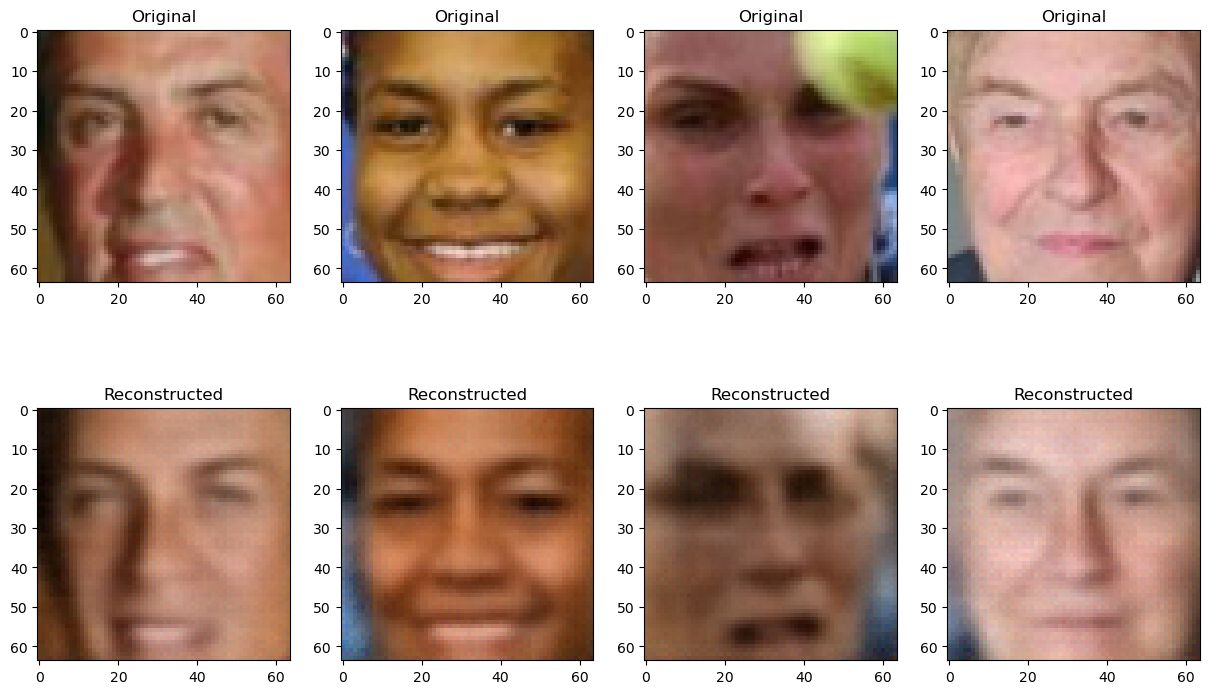

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


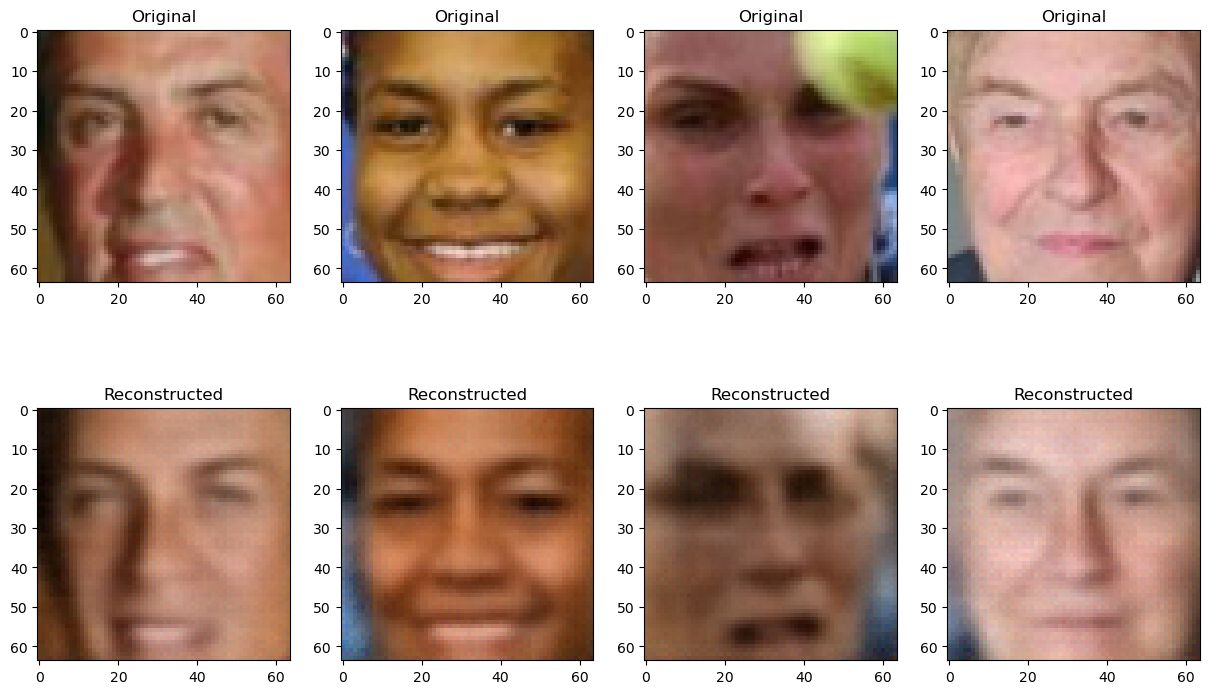

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


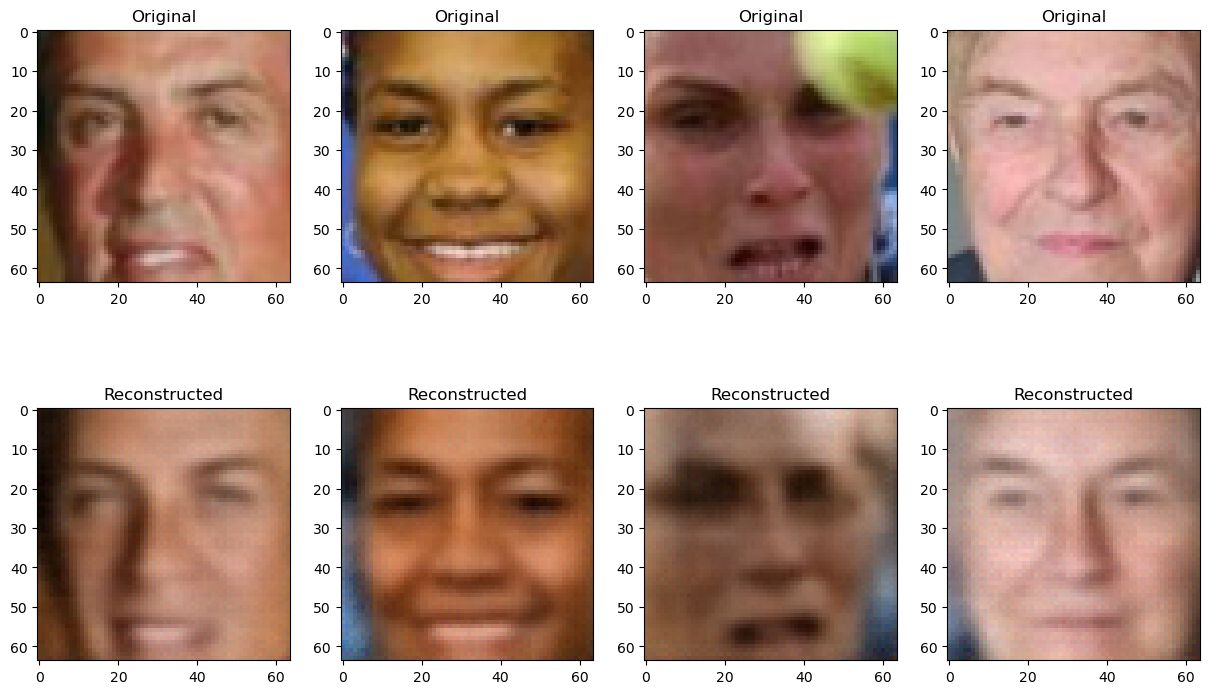

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


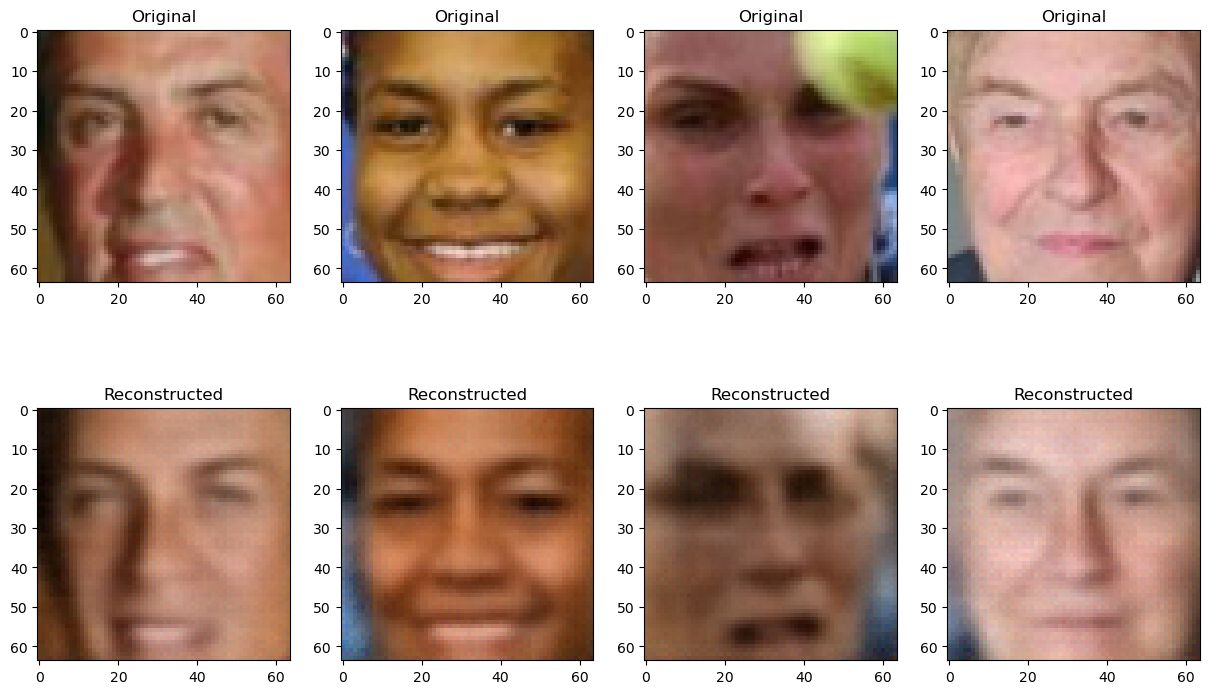

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


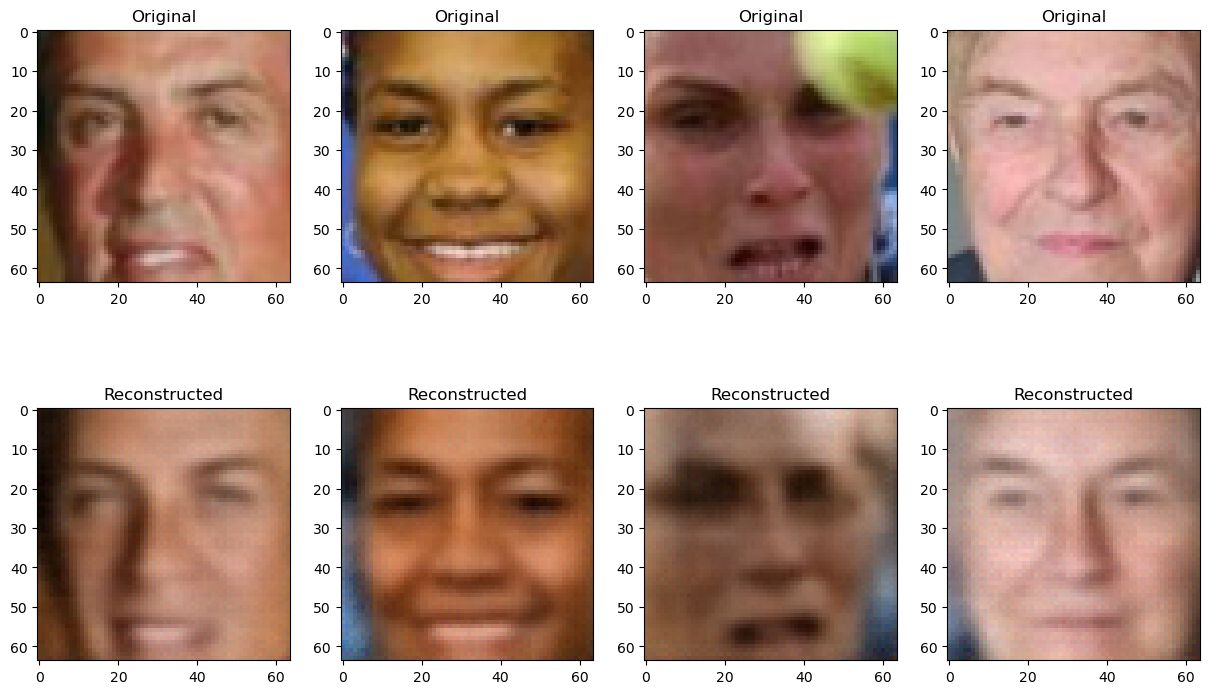

In [177]:
train_losses, val_losses = train(model, optimizer, criterion, 50)

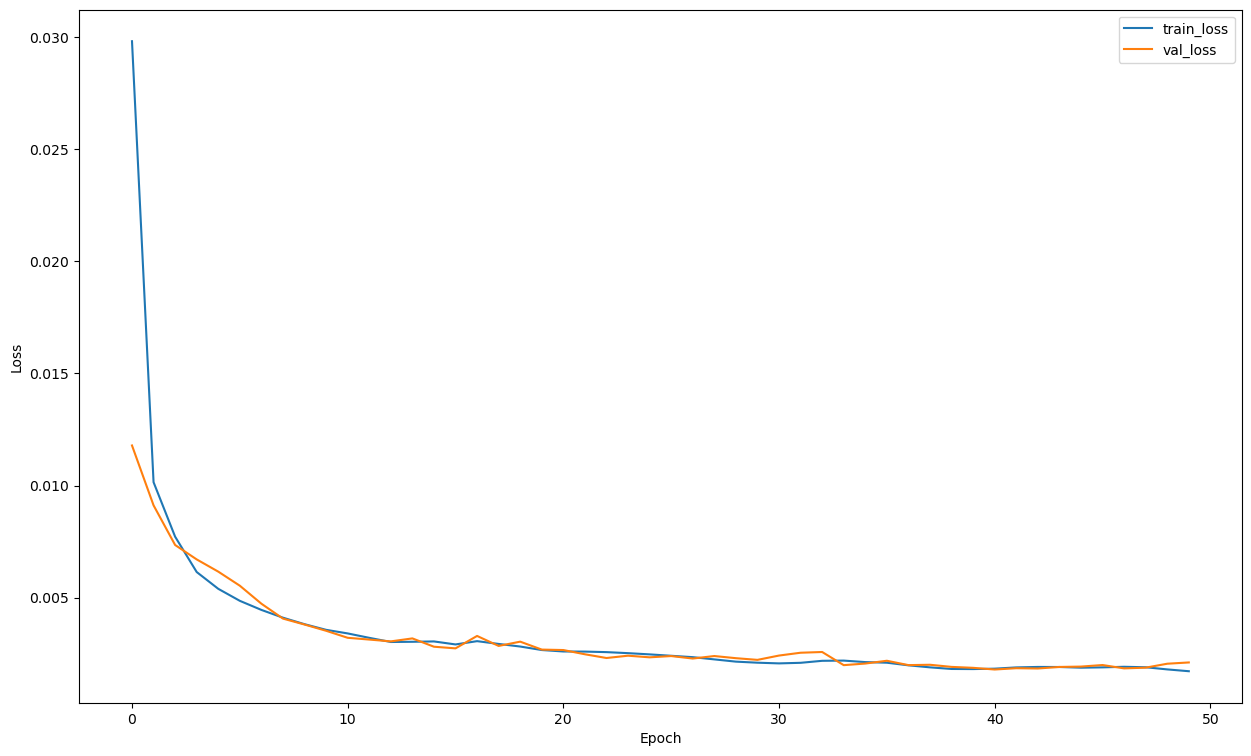

In [178]:
plt.figure(figsize=(15, 9))
plt.plot(train_losses, label="train_loss")
plt.plot(val_losses, label="val_loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


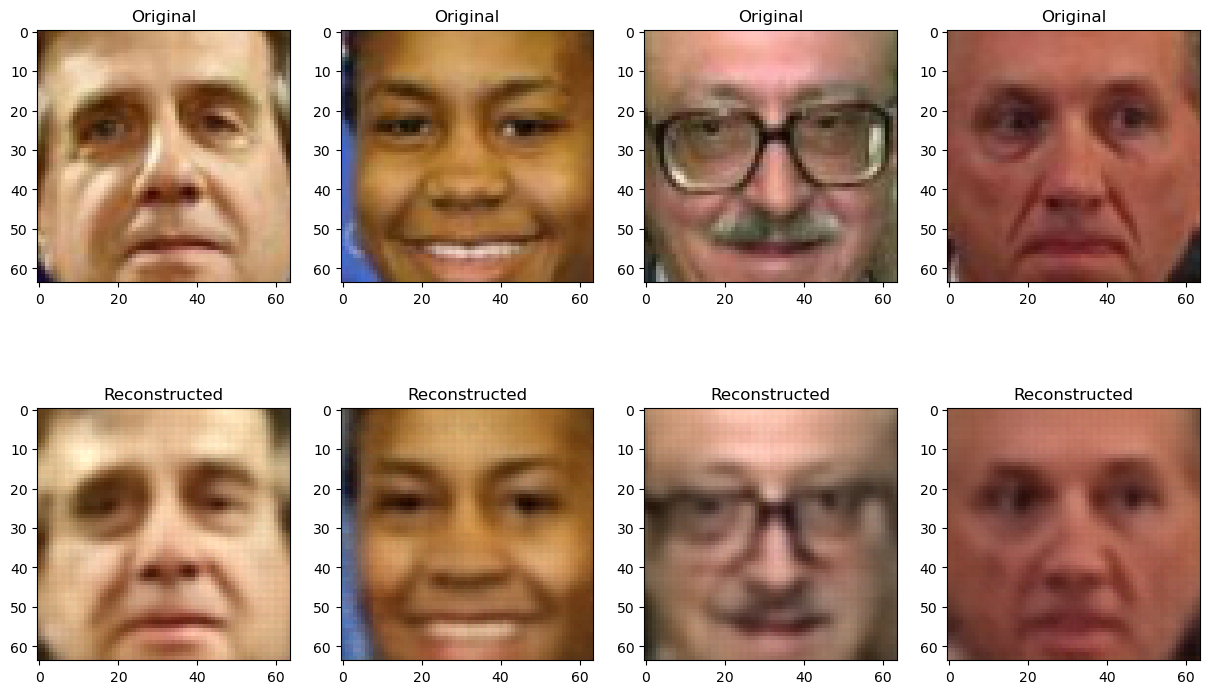

In [179]:
images = []
with torch.no_grad():
    for data in val_loader:
        X_batch = data.to(device)
        rec, _ = model(X_batch)  
        if len(images) < 4:
            n = np.random.randint(0, 32)
            images.append((X_batch[n], rec[n]))

if len(images) == 4:
    plt.figure(figsize=(15, 9))
    for i in range(4):
        plt.subplot(2, 4, i + 1)
        plt.title("Original")
        plt.imshow(images[i][0].permute(1, 2, 0).to("cpu").numpy())
        plt.subplot(2, 4, i + 1 + 4)
        plt.title("Reconstructed")
        plt.imshow(images[i][1].permute(1, 2, 0).to("cpu").numpy())
plt.show();

Not bad, right?

## 1.4. Sampling (2 балла)

Давайте теперь будем не просто брать картинку, прогонять ее через автоэекодер и получать реконструкцию, а попробуем создать что-то НОВОЕ

Давайте возьмем и подсунем декодеру какие-нибудь сгенерированные нами векторы (например, из нормального распределения) и посмотрим на результат реконструкции декодера:

__Подсказка:__Е сли вместо лиц у вас выводится непонятно что, попробуйте посмотреть, как выглядят латентные векторы картинок из датасета. Так как в обучении нейронных сетей есть определенная доля рандома, векторы латентного слоя могут быть распределены НЕ как `np.random.randn(25, <latent_space_dim>)`. А чтобы у нас получались лица при запихивании вектора декодеру, вектор должен быть распределен так же, как латентные векторы реальных фоток. Так что в таком случае придется рандом немного подогнать.

In [180]:
for X_batch in val_loader:
    print(model.encoder(X_batch.to(device)).shape)
    break

torch.Size([32, 256])


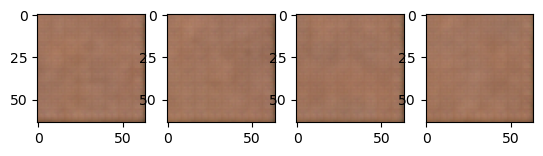

In [181]:
# сгенерируем 25 рандомных векторов размера latent_space
z = np.random.randn(25, 256) 
t = torch.FloatTensor(z).to(device)
output = model.sample(t)
for i in range(4):
    plt.subplot(2, 4, i + 1)
    plt.imshow(output[i].permute(1, 2, 0).to("cpu").detach().numpy())
plt.show();

Рассчитаем мат. ожидание и сигму по распределению признаков реальных латентных векторов

In [182]:
latents = torch.FloatTensor()
iterator = iter(train_loader)
for i in range(len(train_loader)):
    images = next(iterator)
    model.eval()
    with torch.no_grad():
        _, latent_vector = model(images.to(device))
    latents = torch.cat((latents, latent_vector.to('cpu')), dim=0)

mu = torch.mean(latents, axis=0)  
sig = torch.std(latents, axis=0) 

Теперь поменяем семпилрование случайных веторов

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


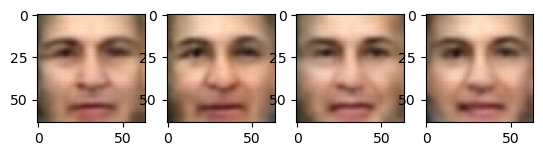

In [183]:
# сгенерируем 25 рандомных векторов размера latent_space
z = 0.3 * sigma * torch.randn(25, 256) + 2 * mu
t = torch.FloatTensor(z).to(device)
output = model.sample(t)
for i in range(4):
    plt.subplot(2, 4, i + 1)
    plt.imshow(output[i].permute(1, 2, 0).to("cpu").detach().numpy())
plt.show();

Получили картинки похожие на лица людей качество не самое лучшее, однако куда лучше, чем было изначально

## 1.5 Time to make fun! (3 балла)

Давайте научимся пририсовывать людям улыбки =)

<img src="https://i.imgur.com/tOE9rDK.png" alt="linear" width="700" height="400">

План такой:

1. Нужно выделить "вектор улыбки": для этого нужно из выборки изображений найти несколько (~15) людей с улыбками и столько же без.

Найти людей с улыбками вам поможет файл с описанием датасета, скачанный вместе с датасетом. В нем указаны имена картинок и присутствубщие атрибуты (улыбки, очки...)

2. Вычислить латентный вектор для всех улыбающихся людей (прогнать их через encoder) и то же для всех грустненьких

3. Вычислить, собственно, вектор улыбки -- посчитать разность между средним латентным вектором улыбающихся людей и средним латентным вектором грустных людей

4. А теперь приделаем улыбку грустному человеку: добавим полученный в пункте 3 вектор к латентному вектору грустного человека и прогоним полученный вектор через decoder. Получим того же человека, но уже не грустненького!

## 1

Обратим внимание на Smiling в колонках attrs

In [188]:
data, attrs = fetch_dataset()

In [189]:
attrs.columns

Index(['Male', 'Asian', 'White', 'Black', 'Baby', 'Child', 'Youth',
       'Middle Aged', 'Senior', 'Black Hair', 'Blond Hair', 'Brown Hair',
       'Bald', 'No Eyewear', 'Eyeglasses', 'Sunglasses', 'Mustache', 'Smiling',
       'Frowning', 'Chubby', 'Blurry', 'Harsh Lighting', 'Flash',
       'Soft Lighting', 'Outdoor', 'Curly Hair', 'Wavy Hair', 'Straight Hair',
       'Receding Hairline', 'Bangs', 'Sideburns', 'Fully Visible Forehead',
       'Partially Visible Forehead', 'Obstructed Forehead', 'Bushy Eyebrows',
       'Arched Eyebrows', 'Narrow Eyes', 'Eyes Open', 'Big Nose',
       'Pointy Nose', 'Big Lips', 'Mouth Closed', 'Mouth Slightly Open',
       'Mouth Wide Open', 'Teeth Not Visible', 'No Beard', 'Goatee',
       'Round Jaw', 'Double Chin', 'Wearing Hat', 'Oval Face', 'Square Face',
       'Round Face', 'Color Photo', 'Posed Photo', 'Attractive Man',
       'Attractive Woman', 'Indian', 'Gray Hair', 'Bags Under Eyes',
       'Heavy Makeup', 'Rosy Cheeks', 'Shiny Skin', 'Pa

In [190]:
attrs['Smiling']

0        -0.86499
1        0.798544
2        0.172817
3        0.563327
4        0.507786
           ...   
13138   -1.001434
13139    -0.64957
13140    0.475018
13141    0.741653
13142   -1.667977
Name: Smiling, Length: 13143, dtype: object

Найдём индексы 15 грустных и улыбчивых людей

In [191]:
smile_id = attrs.sort_values('Smiling', ascending=False).head(15).index.tolist()
sad_id = attrs.sort_values('Smiling', ascending=True).head(15).index.tolist()

Нарисуем этих людей

Улыбающиеся люди

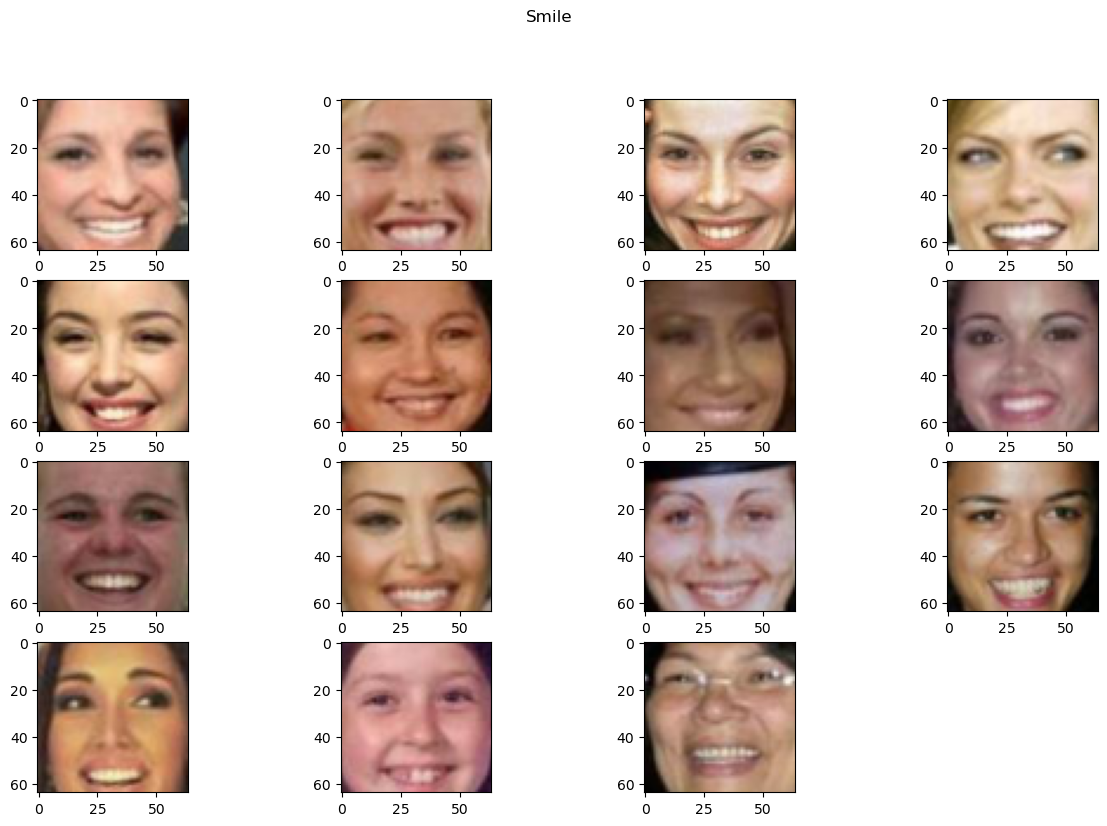

In [192]:
plt.figure(figsize=(15, 9))
plt.suptitle('Smile')
j = 0
for i  in range(15):
    plt.subplot(4, 4, i + 1)
    plt.imshow(data[smile_id[j]])
    j += 1
plt.show()

Грустные люди

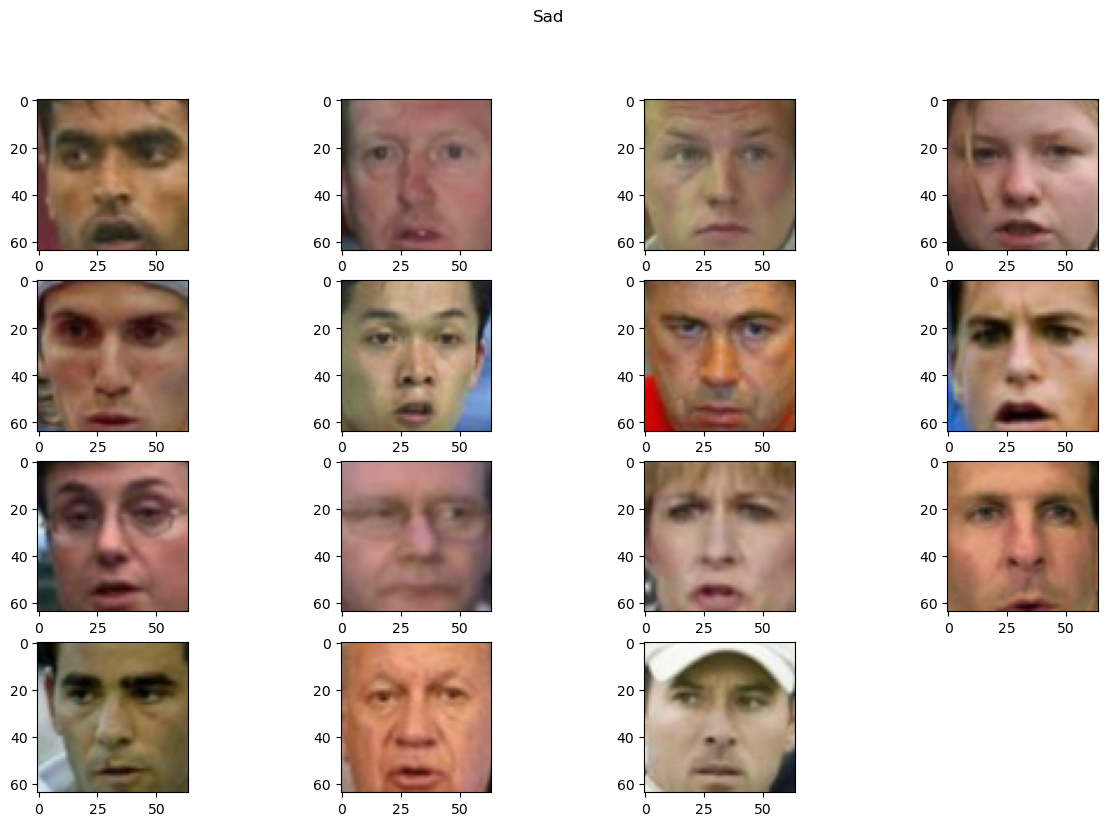

In [193]:
plt.figure(figsize=(15, 9))
plt.suptitle('Sad')
j = 0
for i  in range(15):
    plt.subplot(4, 4, i + 1)
    plt.imshow(data[sad_id[j]])
    j += 1
plt.show()

## 2

In [194]:
smile = torch.FloatTensor().to(device)
sad = torch.FloatTensor().to(device)

for idx in smile_idx:
    smile_image = torch.FloatTensor(data[idx]).permute(2, 0, 1).unsqueeze(0).to(device)
    with torch.no_grad():
        _, l_smile = model(smile_image)

    smile = torch.cat((smile, l_smile))


for idx in sad_idx:
    sad_image = torch.FloatTensor(data[idx]).permute(2, 0, 1).unsqueeze(0).to(device)
    with torch.no_grad():
        _, l_sad = model(sad_image)

    sad = torch.cat((sad, l_sad))

## 3

In [195]:
smile_mean = torch.mean(smile, axis=0)
sad_mean = torch.mean(sad, axis=0)
smile = smile_mean - sad_mean

## 4

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping i

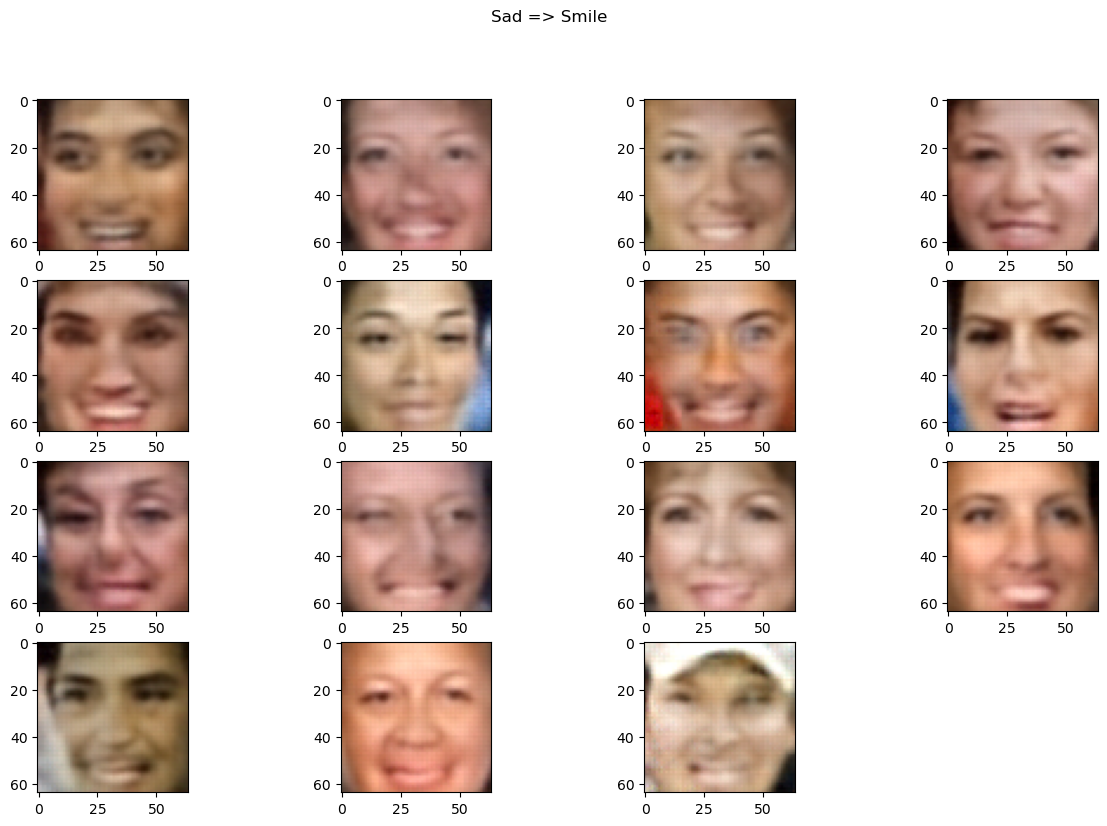

In [196]:
smile1 = sad + smile

with torch.no_grad():
    output = model.sample(smile1)

plt.figure(figsize=(15, 9))
plt.suptitle('Sad => Smile')
for i in range(15):
    plt.subplot(4, 4, i+1)
    plt.imshow(output[i].cpu().permute(1,2,0))
    
plt.show()

Вуаля! Вы восхитительны!

Теперь вы можете пририсовывать людям не только улыбки, но и много чего другого -- закрывать/открывать глаза, пририсовывать очки... в общем, все, на что хватит фантазии и на что есть атрибуты в `all_attrs`:)

# Часть 2: Variational Autoencoder (10 баллов)

Займемся обучением вариационных автоэнкодеров — проапгрейженной версии AE. Обучать будем на датасете MNIST, содержащем написанные от руки цифры от 0 до 9

In [48]:
batch_size = 32
# MNIST Dataset
train_dataset = datasets.MNIST(root='./mnist_data/', train=True, transform=transforms.ToTensor(), download=True)
test_dataset = datasets.MNIST(root='./mnist_data/', train=False, transform=transforms.ToTensor(), download=False)

# Data Loader (Input Pipeline)
train_loader = torch.utils.data.DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
test_loader = torch.utils.data.DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)

## 2.1 Архитектура модели и обучение (2 балла)

Реализуем VAE. Архитектуру (conv, fully-connected, ReLu, etc) можете выбирать сами. Рекомендуем пользоваться более сложными моделями, чем та, что была на семинаре:) Экспериментируйте!

In [49]:
vae_latent_dim = 16

In [61]:
class VAE(nn.Module):
    def __init__(self):
        """<определите архитектуры encoder и decoder
        помните, у encoder должны быть два "хвоста",
        т.е. encoder должен кодировать картинку в 2 переменные -- mu и logsigma>"""
        super().__init__()
        self.encoder = nn.Sequential(
            # количество каналов изображения = 1
            nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3),
            nn.BatchNorm2d(32, momentum=0.1),
            nn.ReLU(),
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3),
            nn.BatchNorm2d(64, momentum=0.1),
            nn.ReLU(),
            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3),
            nn.BatchNorm2d(128, momentum=0.1),
            nn.ReLU(),
            nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3),
            nn.BatchNorm2d(256, momentum=0.1),
            nn.ReLU()
        )

        self.mu = nn.Linear(in_features=256 * 20 * 20, out_features=vae_latent_dim)
        self.logsigma = nn.Linear(in_features=256 * 20 * 20, out_features=vae_latent_dim)
        self.transform_for_decoder = nn.Sequential(
            nn.Linear(in_features=vae_latent_dim, out_features=256 * 20 * 20),
            nn.Unflatten(1, (256, 20, 20))
            )

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(in_channels=256, out_channels=128, kernel_size=3),
            nn.BatchNorm2d(128, momentum=0.1),
            nn.ReLU(),
            nn.ConvTranspose2d(in_channels=128, out_channels=64, kernel_size=3),
            nn.BatchNorm2d(64, momentum=0.1),
            nn.ReLU(),
            nn.ConvTranspose2d(in_channels=64, out_channels=32, kernel_size=3),
            nn.BatchNorm2d(32, momentum=0.1),
            nn.ReLU(),
            nn.ConvTranspose2d(in_channels=32, out_channels=1, kernel_size=3),
            nn.Sigmoid()
        )


    def reparameterize(self, mu, log_var):
        """
        :param mu: mean from the encoder's latent space
        :param log_var: log variance from the encoder's latent space
        """
        std = torch.exp(0.5 * log_var) 
        eps = torch.randn_like(std) 
        sample = mu + (eps * std) 
        return sample

    def encode(self, x):
        #<реализуйте forward проход энкодера
        #в качестве возвращаемых переменных -- mu и logsigma>
        x = self.encoder(x)
        x = torch.flatten(x, start_dim=1)
        mu = self.mu(x)
        logsigma = self.logsigma(x)
        return mu, logsigma

    def gaussian_sampler(self, mu, logsigma):
        if self.training:
            #<засемплируйте латентный вектор из нормального распределения с параметрами mu и sigma>
            return self.reparameterize(mu, logsigma)
        else:
            # на инференсе возвращаем не случайный вектор из нормального распределения, а центральный -- mu.
            # на инференсе выход автоэнкодера должен быть детерминирован.
            return mu

    def decode(self, z):
        #<реализуйте forward проход декодера
        #в качестве возвращаемой переменной -- reconstruction>
        z = self.transform_for_decoder(z)
        reconstruction = self.decoder(z)
        return reconstruction

    def forward(self, x):
        #<используя encode и decode, реализуйте forward проход автоэнкодера
        #в качестве возвращаемых переменных -- mu, logsigma и reconstruction>
        mu, logsigma = self.encode(x)
        sample = self.reparameterize(mu, logsigma)
        reconstruction = self.decode(sample)
        return mu, logsigma, reconstruction

Определим лосс и его компоненты для VAE:

Надеюсь, вы уже прочитали материал в towardsdatascience (или еще где-то) про VAE и знаете, что лосс у VAE состоит из двух частей: KL и log-likelihood.

Общий лосс будет выглядеть так:

$$\mathcal{L} = -D_{KL}(q_{\phi}(z|x)||p(z)) + \log p_{\theta}(x|z)$$

Формула для KL-дивергенции:

$$D_{KL} = -\frac{1}{2}\sum_{i=1}^{dimZ}(1+log(\sigma_i^2)-\mu_i^2-\sigma_i^2)$$

В качестве log-likelihood возьмем привычную нам кросс-энтропию.

In [51]:
def KL_divergence(mu, logsigma):
    """
    часть функции потерь, которая отвечает за "близость" латентных представлений разных людей
    """
    loss = -0.5 * torch.sum(1 + logsigma - mu.pow(2) - logsigma.exp())
    return loss

def log_likelihood(x, reconstruction):
    """
    часть функции потерь, которая отвечает за качество реконструкции
    """
    loss = nn.BCELoss(reduction='sum')
    return loss(reconstruction, x)

def loss_vae(x, mu, logsigma, reconstruction):
    return KL_divergence(mu, logsigma) + log_likelihood(x, reconstruction)

И обучим модель:

In [52]:
def train(model, criterion, optimizer, train_loader, val_loader, max_epochs):
    train_losses = []
    val_losses = []
    for epoch in tqdm(range(max_epochs)):
        model.train()
        train_losses_per_epoch = []
        for X_batch in train_loader:
            X_batch, label = X_batch
            X_batch = X_batch.to(device)
            optimizer.zero_grad()
            mu, logsigma, reconstruction = model(X_batch)
            loss = criterion(X_batch, mu, logsigma, reconstruction)
            loss.backward()
            optimizer.step()
            if loss.item() > 10**32:
                print("train", loss.item())
            else:
                train_losses_per_epoch.append(loss.item())
        mean_train_loss_epoch = np.mean(train_losses_per_epoch)
        print("Train loss", mean_train_loss_epoch)
        train_losses.append(mean_train_loss_epoch)


        model.eval()
        val_losses_per_epoch = []
        show_reconstruction = []
        with torch.no_grad():
            for X_batch in val_loader:
                X_batch, label = X_batch
                X_batch = X_batch.to(device)
                mu, logsigma, reconstruction = model(X_batch)
                loss = criterion(X_batch, mu, logsigma, reconstruction)
                if loss.item() > 10**32:
                    print("test", loss.item())
                else:
                    val_losses_per_epoch.append(loss.item())
                if len(show_reconstruction) < 4 and ((epoch + 1) % 10 == 0 or epoch == 0):
                    n = np.random.randint(0, batch_size)
                    show_reconstruction.append((X_batch[n], reconstruction[n]))
        mean_val_loss_epoch = np.mean(val_losses_per_epoch)
        print("Val loss", mean_val_loss_epoch)
        val_losses.append(mean_val_loss_epoch)

        if len(show_reconstruction) == 4 and ((epoch + 1) % 10 == 0 or epoch == 0):
            plt.figure(figsize=(9, 6))
            plt.title(f"Epoch №{epoch + 1}")
            plt.tick_params (left=False, bottom=False, labelleft=False, labelbottom=False)
            for i in range(4):
                plt.subplot(2, 4, i + 1)
                plt.title("Original picture")
                plt.imshow(show_reconstruction[i][0].permute(1, 2, 0).to("cpu").numpy())
                plt.subplot(2, 4, i + 1 + 4)
                plt.title("Reconstructed")
                plt.imshow(show_reconstruction[i][1].permute(1, 2, 0).to("cpu").numpy())
            plt.show();
    return train_losses, val_losses


In [53]:
device = 'cuda:0' if torch.cuda.is_available() else 'cpu'

criterion = loss_vae

model = VAE().to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=3e-5) # <Ваш любимый оптимизатор>

  0%|          | 0/50 [00:00<?, ?it/s]

Train loss 5134.8390953125
Val loss 4138.403092551917


C:\Users\Игорь\AppData\Local\Temp\ipykernel_16336\1707196194.py:49: MatplotlibDeprecationWarning: Auto-removal of overlapping axes is deprecated since 3.6 and will be removed two minor releases later; explicitly call ax.remove() as needed.
  plt.subplot(2, 4, i + 1)


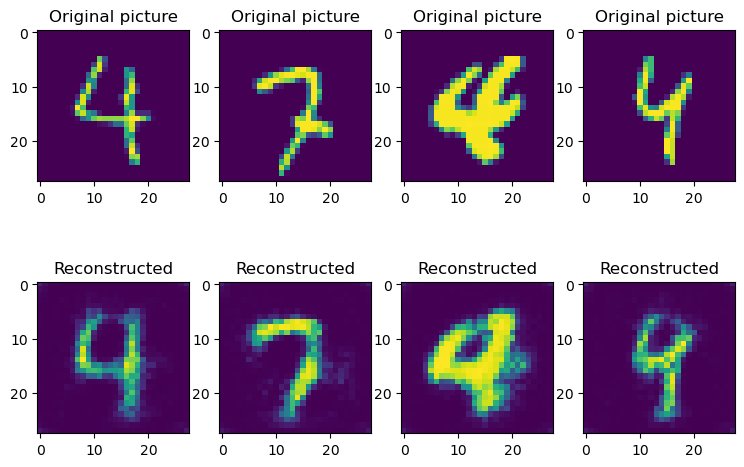

Train loss 3933.5177548177085
Val loss 3740.7915702064197
Train loss 3692.6041884114584
Val loss 3579.799832767572
Train loss 3568.636080338542
Val loss 3525.972386369309
Train loss 3489.404945442708
Val loss 3485.6229290946985
Train loss 3434.384366796875
Val loss 3402.4830002464805
Train loss 3395.00119453125
Val loss 3352.491510458267
Train loss 3357.7771490885416
Val loss 3363.947012904353
Train loss 3330.175507421875
Val loss 3344.374943059854
Train loss 3307.0661212239584
Val loss 3282.490921166758


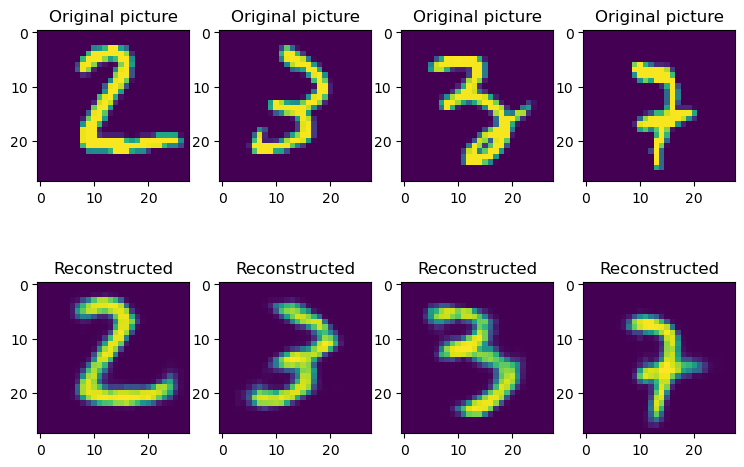

Train loss 3284.0883104166664
Val loss 3275.092089375749
Train loss 3266.6479313802083
Val loss 3259.680336461661
Train loss 3252.142992708333
Val loss 3255.5406888041634
Train loss 3232.90134140625
Val loss 3245.216485264202
Train loss 3221.0122803385416
Val loss 3234.6301803832616
Train loss 3209.3880020833335
Val loss 3229.946106542033
Train loss 3198.6646657552083
Val loss 3233.1612256327376
Train loss 3188.152531640625
Val loss 3242.0811170876595
Train loss 3177.817317708333
Val loss 3208.1588216665837
Train loss 3170.358437890625
Val loss 3213.009480924271


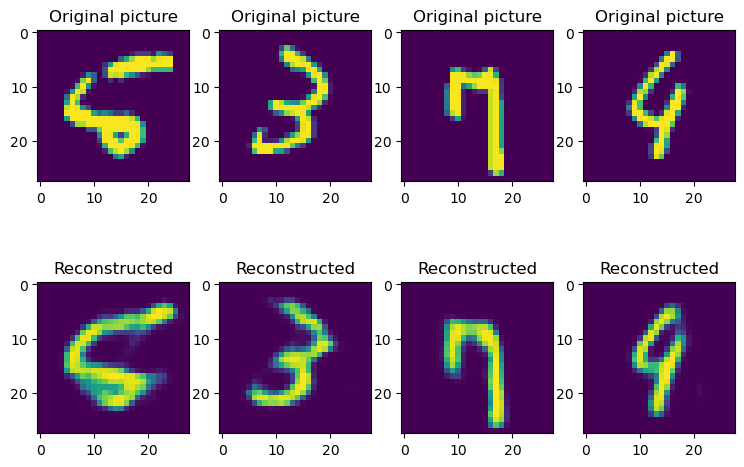

Train loss 3161.588353125
Val loss 3203.850410437051
Train loss 3154.474501041667
Val loss 3189.737366307658
Train loss 3147.8354544270833
Val loss 3184.6374913419777
Train loss 3139.0380092447917
Val loss 3188.009491844299
Train loss 3134.130494140625
Val loss 3173.352386962111
Train loss 3128.54385625
Val loss 3169.067304032298
Train loss 3122.4534981770835
Val loss 3175.0377162165537
Train loss 3118.0895654947917
Val loss 3177.552724624975
Train loss 3110.4416739583335
Val loss 3158.634040223143
Train loss 3106.0052052083333
Val loss 3164.648154359275


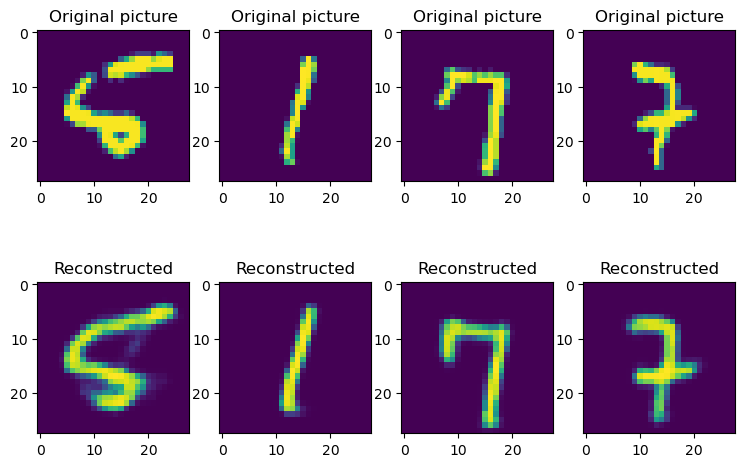

Train loss 3102.2729177083334
Val loss 3163.080536766174
Train loss 3097.2739940104166
Val loss 3158.028610083242
Train loss 3091.594853645833
Val loss 3154.3937013278755
Train loss 3088.579620182292
Val loss 3156.2774724503297
Train loss 3084.507276171875
Val loss 3168.186530457518
Train loss 3080.8593380208335
Val loss 3148.823919229233
Train loss 3076.9368518229167
Val loss 3140.1376524123903
Train loss 3072.47638984375
Val loss 3142.068124594399
Train loss 3068.0050986979168
Val loss 3143.0672697122104
Train loss 3065.576534505208
Val loss 3168.1883182220945


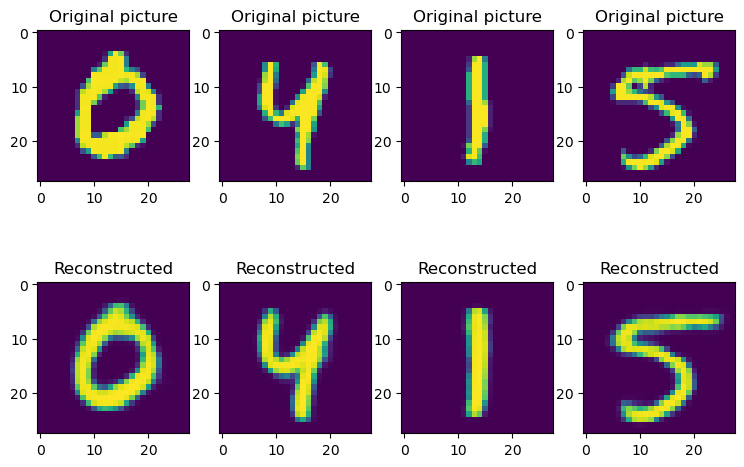

Train loss 3062.393839453125
Val loss 3158.773884831145
Train loss 3059.504115625
Val loss 3138.1382366338858
Train loss 3055.724462890625
Val loss 3136.972337619184
Train loss 3053.80833203125
Val loss 3138.204857384435
Train loss 3050.128408203125
Val loss 3157.0200390313
Train loss 3046.9226313802083
Val loss 3142.9983237757087
Train loss 3043.406294140625
Val loss 3135.8726061738716
Train loss 3041.9410763020833
Val loss 3130.6282561183357
Train loss 3039.5906473958335
Val loss 3128.310993036142
Train loss 3036.8459555989584
Val loss 3126.771484375


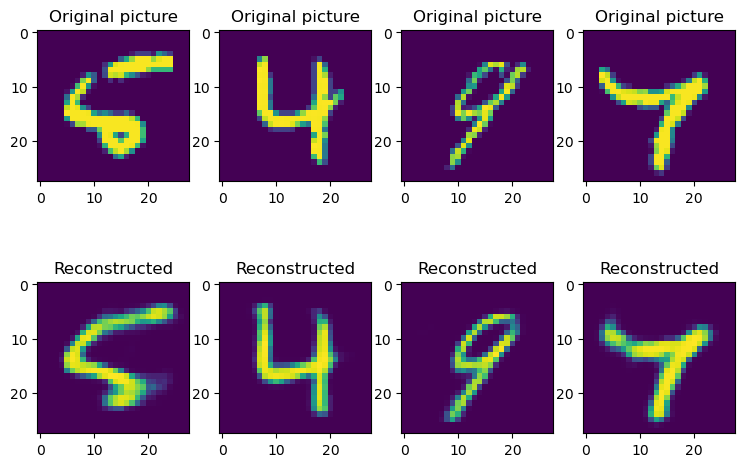

In [54]:
train_losses, val_losses = train(model, criterion, optimizer, train_loader, test_loader, 50)


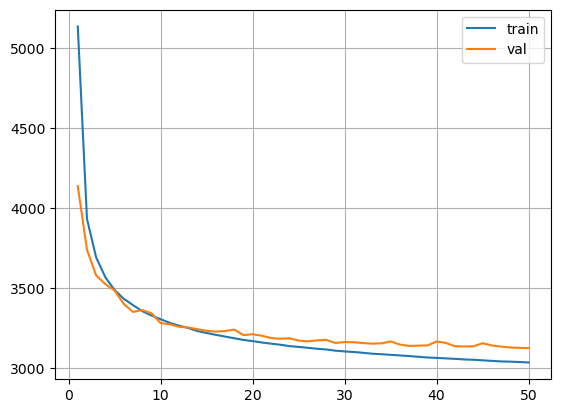

In [74]:
plt.plot([i for i in range(1, len(train_losses) + 1)], train_losses, label="train")
plt.plot([i for i in range(1, len(val_losses) + 1)], val_losses, label="val")
plt.grid()
plt.legend()
plt.show();

Давайте попробуем проделать для VAE то же, что и с обычным автоэнкодером -- подсунуть decoder'у из VAE случайные векторы из нормального распределения и посмотреть, какие картинки получаются:

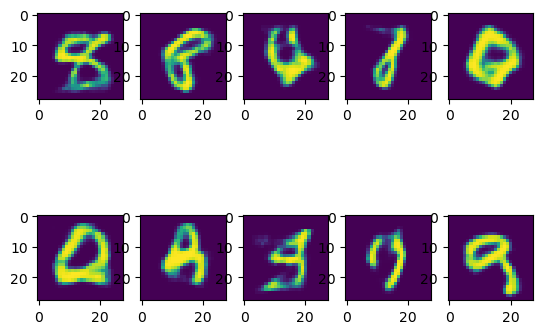

In [55]:
# вспомните про замечание из этого же пункта обычного AE про распределение латентных переменных
z = torch.Tensor(np.array([np.random.normal(0, 1, 16) for i in range(10)])).to(device)
output = model.decode(z)#<скормите z декодеру>
#<выведите тут полученные картинки>
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(output[i].permute(1, 2, 0).to("cpu").detach().numpy())
plt.show();

## 2.2. Latent Representation (2 балла)

Давайте посмотрим, как латентные векторы картинок лиц выглядят в пространстве.
Ваша задача -- изобразить латентные векторы картинок точками в двумерном просторанстве.

Это позволит оценить, насколько плотно распределены латентные векторы изображений цифр в пространстве.

Плюс давайте сделаем такую вещь: покрасим точки, которые соответствуют картинкам каждой цифры, в свой отдельный цвет

Подсказка: красить -- это просто =) У plt.scatter есть параметр c (color), см. в документации.


Итак, план:
1. Получить латентные представления картинок тестового датасета
2. С помощтю `TSNE` (есть в `sklearn`) сжать эти представления до размерности 2 (чтобы можно было их визуализировать точками в пространстве)
3. Визуализировать полученные двумерные представления с помощью `matplotlib.scatter`, покрасить разными цветами точки, соответствующие картинкам разных цифр.

In [56]:
#<ваш код получения латентных представлений, применения TSNE и визуализации>
vectors = torch.FloatTensor([]).to(device)
labels = torch.IntTensor([]).to(device)
for X_batch in test_loader:
    X_batch, label = X_batch
    X_batch, label = X_batch.to(device), label.to(device)
    model.eval()
    with torch.no_grad():
        vec = model.reparameterize(*model.encode(X_batch))
    vectors = torch.cat((vectors, vec))
    labels = torch.cat((labels, label.flatten()))

In [57]:
from sklearn.manifold import TSNE

In [58]:
X_embedded = TSNE().fit_transform(vectors.to("cpu"))

In [59]:
colors = ["navy", "yellow", "blue", "coral", "olive", "green", "indigo", "tan", "violet", "red"]
mask = [False for i in range(10)]

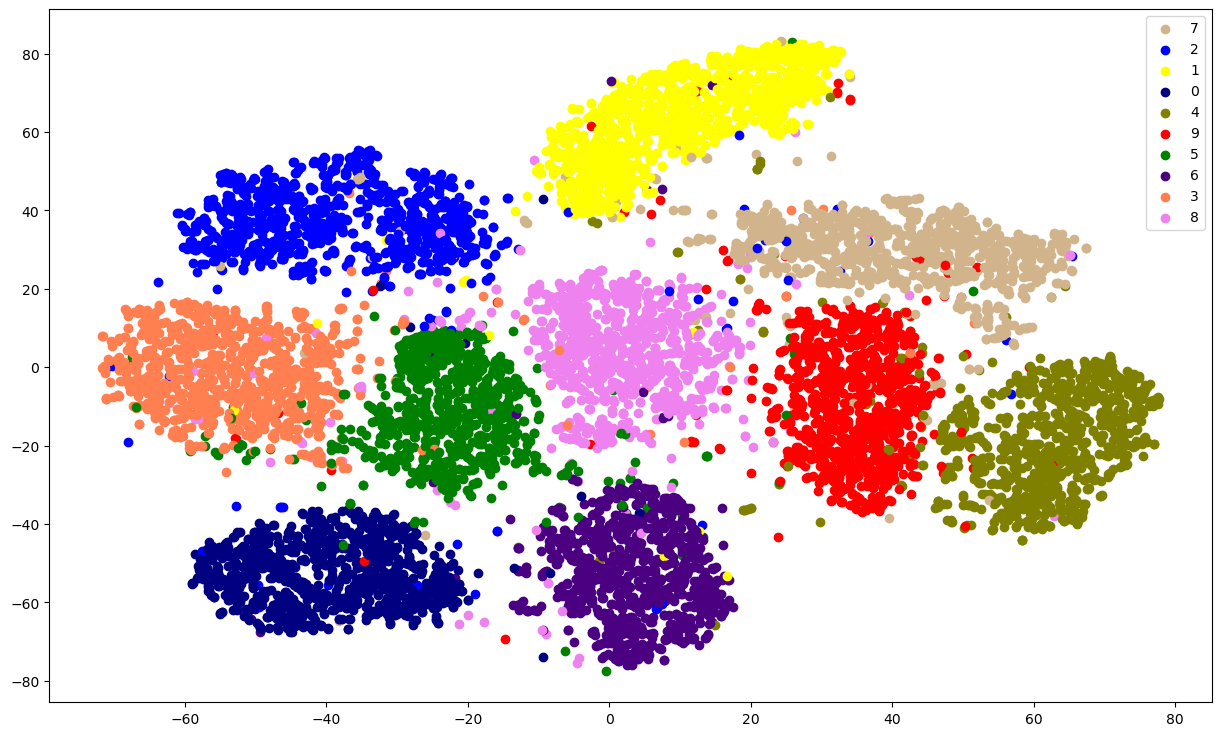

In [60]:
plt.figure(figsize=(15, 9))
for i in range(len(labels)):
    if mask[labels[i]]:
        plt.scatter(X_embedded[i][0], X_embedded[i][1], c=colors[labels[i]])
    else:
        mask[labels[i]] = True
        plt.scatter(X_embedded[i][0], X_embedded[i][1], c=colors[labels[i]], label=labels[i].item())
plt.legend()
plt.show();

__Congrats v2.0!__

Что вы думаете о виде латентного представления?
1) Полученные кластеры хорошо различимы
2) Цифры которые имеют не только ровные линии различаються хуже, чем цифры, которые состоят просто из прямых линий
3) Из-за этого наиболее точно различаються цифры 1, 4

## 2.3. Conditional VAE (6 баллов)


Мы уже научились обучать обычный AE на датасете картинок и получать новые картинки, используя генерацию шума и декодер.
Давайте теперь допустим, что мы обучили AE на датасете MNIST и теперь хотим генерировать новые картинки с числами с помощью декодера (как выше мы генерили рандомные лица).
И вот нам понадобилось сгенерировать цифру 8, и мы подставляем разные варианты шума, но восьмерка никак не генерится:(

Хотелось бы добавить к нашему AE функцию "выдай мне рандомное число из вот этого вот класса", где классов десять (цифры от 0 до 9 образуют десять классов).  Conditional AE — так называется вид автоэнкодера, который предоставляет такую возможность. Ну, название "conditional" уже говорит само за себя.

И в этой части задания мы научимся такие обучать.

### Архитектура

На картинке ниже представлена архитектура простого Conditional VAE.

По сути, единственное отличие от обычного -- это то, что мы вместе с картинкой в первом слое энкодера и декодера передаем еще информацию о классе картинки.

То есть, в первый (входной) слой энкодера подается конкатенация картинки и информации о классе (например, вектора из девяти нулей и одной единицы). В первый слой декодера подается конкатенация латентного вектора и информации о классе.


![alt text](https://sun9-63.userapi.com/impg/Mh1akf7mfpNoprrSWsPOouazSmTPMazYYF49Tw/djoHNw_9KVA.jpg?size=1175x642&quality=96&sign=e88baec5f9bb91c8443fba31dcf0a4df&type=album)

![alt text](https://sun9-73.userapi.com/impg/UDuloLNKhzTBYAKewgxke5-YPsAKyGOqA-qCRg/MnyCavJidxM.jpg?size=1229x651&quality=96&sign=f2d21bfacc1c5755b76868dc4cfef39c&type=album)



На всякий случай: это VAE, то есть, latent у него все еще состоит из mu и sigma

Таким образом, при генерации новой рандомной картинки мы должны будем передать декодеру сконкатенированные латентный вектор и класс картинки.

P.S. Также можно передавать класс картинки не только в первый слой, но и в каждый слой сети. То есть на каждом слое конкатенировать выход из предыдущего слоя и информацию о классе.

In [62]:
vae_latent_dim = 16

In [85]:
class CVAE(nn.Module):
    def __init__(self):
        """<определите архитектуры encoder и decoder
        помните, у encoder должны быть два "хвоста",
        т.е. encoder должен кодировать картинку в 2 переменные -- mu и logsigma>"""
        super(CVAE, self).__init__()
        self.encoder = nn.Sequential(
            # количество каналов изображения = 1
            nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3),
            nn.BatchNorm2d(32, momentum=0.1),
            nn.ReLU(),
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3),
            nn.BatchNorm2d(64, momentum=0.1),
            nn.ReLU(),
            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3),
            nn.BatchNorm2d(128, momentum=0.1),
            nn.ReLU(),
            nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3),
            nn.BatchNorm2d(256, momentum=0.1),
            nn.ReLU()
        )

        self.mu = nn.Linear(in_features=256 * 20 * 20, out_features=vae_latent_dim)
        self.logsigma = nn.Linear(in_features=256 * 20 * 20, out_features=vae_latent_dim)
        self.transform_for_decoder = nn.Sequential(
            nn.Linear(in_features=vae_latent_dim + 10, out_features=256 * 20 * 20),
            nn.Unflatten(1, (256, 20, 20))
            )

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(in_channels=256, out_channels=128, kernel_size=3),
            nn.BatchNorm2d(128, momentum=0.1),
            nn.ReLU(),
            nn.ConvTranspose2d(in_channels=128, out_channels=64, kernel_size=3),
            nn.BatchNorm2d(64, momentum=0.1),
            nn.ReLU(),
            nn.ConvTranspose2d(in_channels=64, out_channels=32, kernel_size=3),
            nn.BatchNorm2d(32, momentum=0.1),
            nn.ReLU(),
            nn.ConvTranspose2d(in_channels=32, out_channels=1, kernel_size=3),
            nn.Sigmoid()
        )


    def reparameterize(self, mu, log_var):
        """
        :param mu: mean from the encoder's latent space
        :param log_var: log variance from the encoder's latent space
        """
        std = torch.exp(0.5 * log_var) # standard deviation
        eps = torch.randn_like(std) # `randn_like` as we need the same size
        sample = mu + (eps * std) # sampling as if coming from the input space
        return sample

    def encode(self, x):
        #<реализуйте forward проход энкодера
        #в качестве возвращаемых переменных -- mu и logsigma>
        x = self.encoder(x)
        x = torch.flatten(x, start_dim=1)
        mu = self.mu(x)
        logsigma = self.logsigma(x)
        return mu, logsigma

    def gaussian_sampler(self, mu, logsigma):
        if self.training:
            #<засемплируйте латентный вектор из нормального распределения с параметрами mu и sigma>
            return self.reparameterize(mu, logsigma)
        else:
            # на инференсе возвращаем не случайный вектор из нормального распределения, а центральный -- mu.
            # на инференсе выход автоэнкодера должен быть детерминирован.
            return mu

    def decode(self, z, labels):
        #<реализуйте forward проход декодера
        #в качестве возвращаемой переменной -- reconstruction>
        labels = F.one_hot(labels, num_classes=10)
        z = torch.cat((labels, z), dim=1)
        z = self.transform_for_decoder(z)
        reconstruction = self.decoder(z)
        return reconstruction

    def forward(self, x, labels):
        #<используя encode и decode, реализуйте forward проход автоэнкодера
        #в качестве возвращаемых переменных -- mu, logsigma и reconstruction>
        mu, logsigma = self.encode(x)
        sample = self.reparameterize(mu, logsigma)
        reconstruction = self.decode(sample, labels)
        return mu, logsigma, reconstruction

In [92]:
def train(model, criterion, optimizer, train_loader, val_loader, max_epochs):
    train_losses = []
    val_losses = []
    for epoch in tqdm(range(max_epochs)):
        model.train()
        train_losses_per_epoch = []
        for X_batch in train_loader:
            X_batch, labels = X_batch
            X_batch, labels = X_batch.to(device), labels.to(device)
            optimizer.zero_grad()
            mu, logsigma, reconstruction = model(X_batch, labels)
            loss = criterion(X_batch, mu, logsigma, reconstruction)
            loss.backward()
            optimizer.step()
            if loss.item() > 10**32:
                print("train", loss.item())
            else:
                train_losses_per_epoch.append(loss.item())
        mean_train_loss_epoch = np.mean(train_losses_per_epoch)
        print("Train loss", mean_train_loss_epoch)
        train_losses.append(mean_train_loss_epoch)


        model.eval()
        val_losses_per_epoch = []
        show_reconstruction = []
        with torch.no_grad():
            for X_batch in val_loader:
                X_batch, labels = X_batch
                X_batch, labels = X_batch.to(device), labels.to(device)
                mu, logsigma, reconstruction = model(X_batch, labels)
                loss = criterion(X_batch, mu, logsigma, reconstruction)
                if loss.item() > 10**32:
                    print("test", loss.item())
                else:
                    val_losses_per_epoch.append(loss.item())
                if len(show_reconstruction) < 4 and ((epoch + 1) % 10 == 0 or epoch == 0):
                    n = np.random.randint(0, batch_size)
                    show_reconstruction.append((X_batch[n], reconstruction[n]))
        mean_val_loss_epoch = np.mean(val_losses_per_epoch)
        print("Val loss", mean_val_loss_epoch)
        val_losses.append(mean_val_loss_epoch)

        if len(show_reconstruction) == 4 and ((epoch + 1) % 10 == 0 or epoch == 0):
            plt.figure(figsize=(9, 6))
            plt.title(f"Epoch №{epoch + 1}")
            plt.tick_params (left=False, bottom=False, labelleft=False, labelbottom=False)
            for i in range(4):
                plt.subplot(2, 4, i + 1)
                plt.title("Original picture")
                plt.imshow(show_reconstruction[i][0].permute(1, 2, 0).to("cpu").numpy())
                plt.subplot(2, 4, i + 1 + 4)
                plt.title("Reconstructed")
                plt.imshow(show_reconstruction[i][1].permute(1, 2, 0).to("cpu").numpy())
            plt.show();
    return train_losses, val_losses


In [93]:
criterion = loss_vae

model1 = CVAE().to(device)

optimizer1 = torch.optim.Adam(model1.parameters(), lr=3e-5)

  0%|          | 0/50 [00:00<?, ?it/s]

Train loss 5391.128953515625
Val loss 4148.524718263278


C:\Users\Игорь\AppData\Local\Temp\ipykernel_16336\2150564170.py:49: MatplotlibDeprecationWarning: Auto-removal of overlapping axes is deprecated since 3.6 and will be removed two minor releases later; explicitly call ax.remove() as needed.
  plt.subplot(2, 4, i + 1)


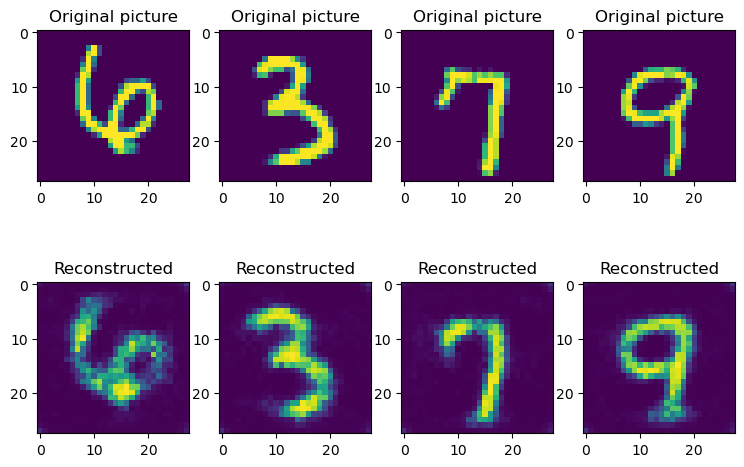

Train loss 3948.389102734375
Val loss 3718.561797998203
Train loss 3676.5223444010417
Val loss 3607.3883286741216
Train loss 3542.393993229167
Val loss 3439.788170567717
Train loss 3458.582540234375
Val loss 3479.8536337953024
Train loss 3393.804024479167
Val loss 3437.3211432021267
Train loss 3347.361711328125
Val loss 3293.8629076290435
Train loss 3306.5947596354167
Val loss 3294.7939843126
Train loss 3274.2769515625
Val loss 3253.88741802179
Train loss 3246.66981171875
Val loss 3238.150567295452


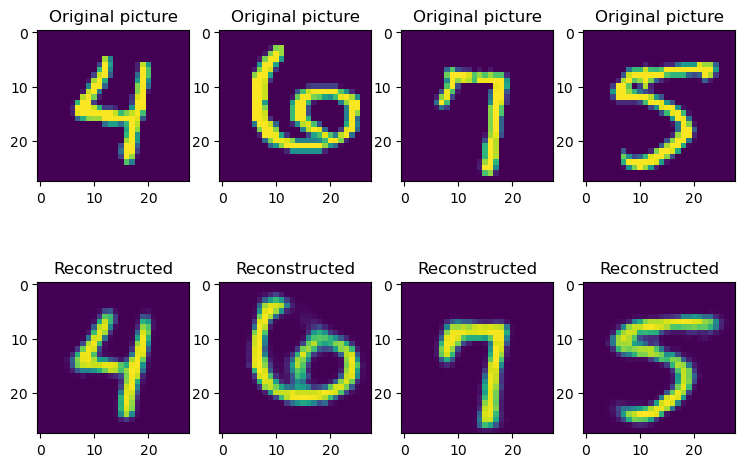

Train loss 3219.5775928385415
Val loss 3230.4905678258538
Train loss 3198.8409358072918
Val loss 3195.9784680448784
Train loss 3180.76884609375
Val loss 3177.0403787533696
Train loss 3161.303477604167
Val loss 3188.7300994190546
Train loss 3146.0011930989585
Val loss 3169.864288232578
Train loss 3133.8189897135417
Val loss 3149.4183267709163
Train loss 3119.429258984375
Val loss 3144.468792120108
Train loss 3109.0606127604165
Val loss 3134.6999956319887
Train loss 3096.9650072916666
Val loss 3117.7953032959763
Train loss 3085.906915234375
Val loss 3127.508971972968


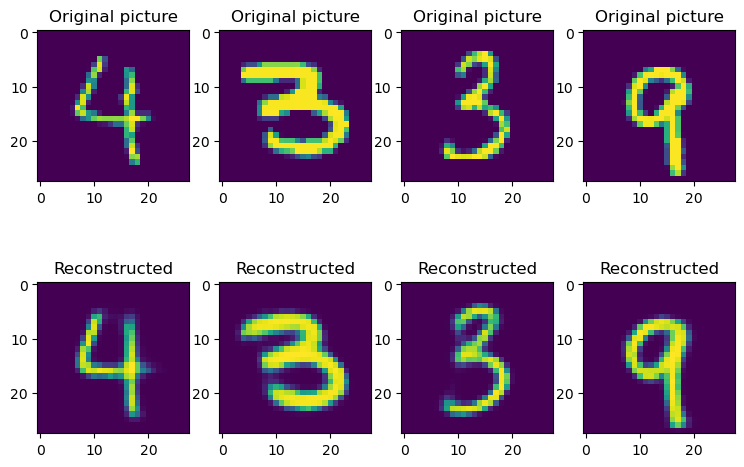

Train loss 3078.1354859375
Val loss 3111.150899186302
Train loss 3068.755097265625
Val loss 3113.315602067941
Train loss 3061.2118994791667
Val loss 3109.725567997454
Train loss 3049.7174229166667
Val loss 3087.4328121879994
Train loss 3044.859220442708
Val loss 3096.24735540323
Train loss 3037.2960266927084
Val loss 3088.446025421825
Train loss 3029.6554368489583
Val loss 3090.260976968101
Train loss 3024.058223307292
Val loss 3079.2418220690647
Train loss 3016.881278515625
Val loss 3081.9427002733128
Train loss 3012.9055729166666
Val loss 3087.909889879318


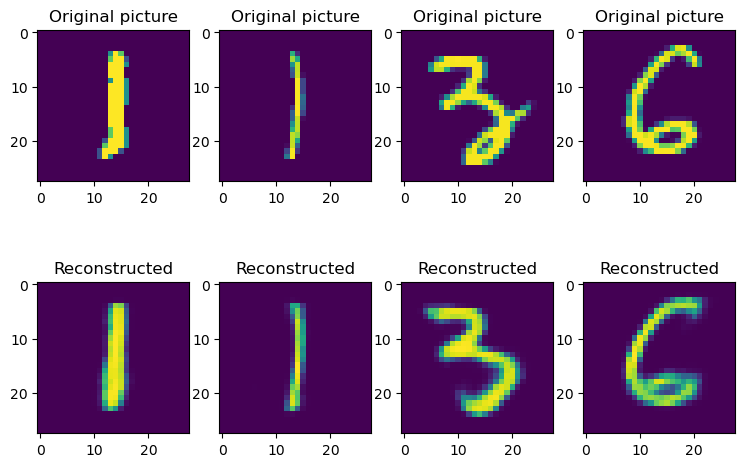

Train loss 3005.394376692708
Val loss 3068.7545084115413
Train loss 2999.2969532552083
Val loss 3071.9297686202076
Train loss 2995.5616947916665
Val loss 3060.984936211437
Train loss 2989.0512930989585
Val loss 3074.3045611396765
Train loss 2984.32772265625
Val loss 3057.622893214607
Train loss 2981.296259635417
Val loss 3057.882476319139
Train loss 2975.56878046875
Val loss 3059.274238562051
Train loss 2970.1865009114586
Val loss 3055.706243447983
Train loss 2967.1339803385417
Val loss 3062.1448697708665
Train loss 2962.3549953125
Val loss 3044.994169485074


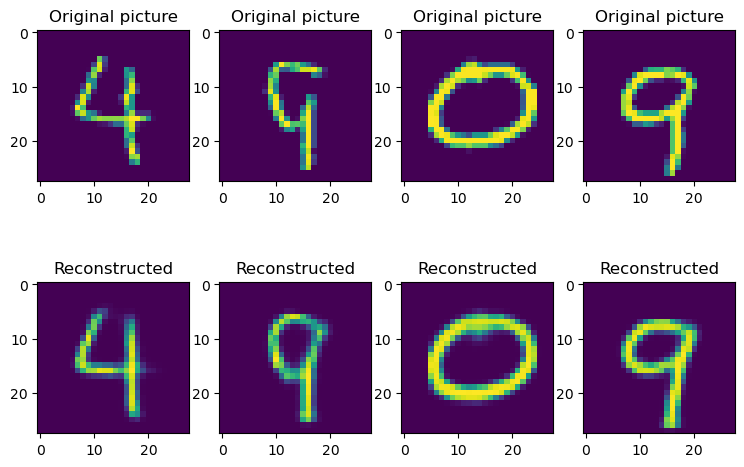

Train loss 2959.0560234375
Val loss 3058.9251471083767
Train loss 2955.0464266927083
Val loss 3043.9066080209163
Train loss 2951.16600390625
Val loss 3040.103950086112
Train loss 2947.2185888020836
Val loss 3051.789973542332
Train loss 2944.795738151042
Val loss 3050.1968931740466
Train loss 2940.5248514322916
Val loss 3034.724114073732
Train loss 2937.1859342447915
Val loss 3038.194581638129
Train loss 2933.302233072917
Val loss 3033.0296034157845
Train loss 2930.4152388020834
Val loss 3043.976273119259
Train loss 2927.635022005208
Val loss 3036.3796858619958


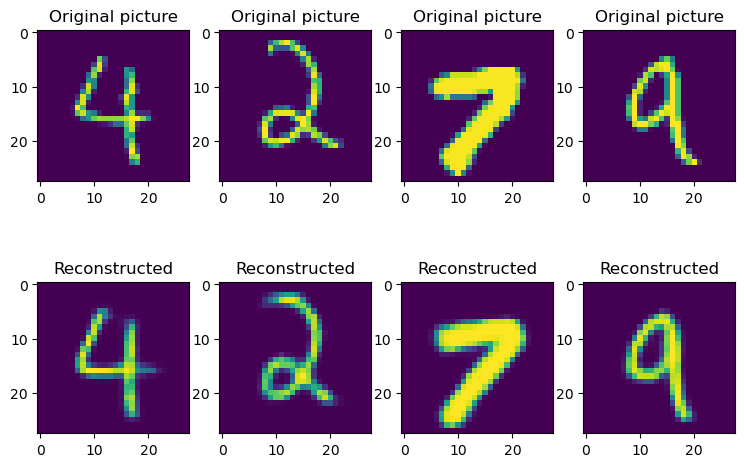

In [94]:
train_losses2, val_losses2 = train(model1, criterion, optimizer1, train_loader, test_loader, 50)

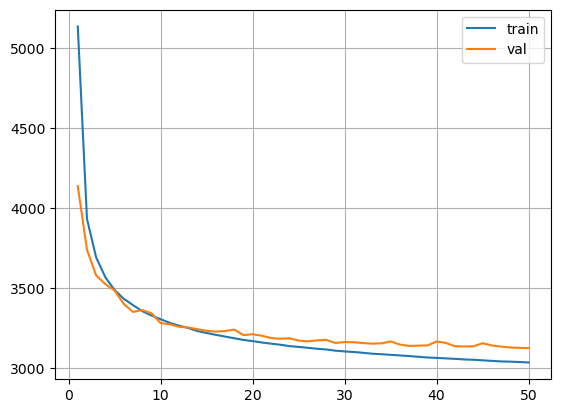

In [95]:
plt.plot([i for i in range(1, len(train_losses2) + 1)], train_losses, label="train")
plt.plot([i for i in range(1, len(val_losses2) + 1)], val_losses, label="val")
plt.grid()
plt.legend()
plt.show();

### Sampling


Тут мы будем сэмплировать из CVAE. Это прикольнее, чем сэмплировать из простого AE/VAE: тут можно взять один и тот же латентный вектор и попросить CVAE восстановить из него картинки разных классов!
Для MNIST вы можете попросить CVAE восстановить из одного латентного вектора, например, картинки цифры 5 и 7.

In [102]:
z = torch.Tensor(np.array([np.random.normal(0, 1, vae_latent_dim) for i in range(10)])).to(device)
labels = torch.IntTensor(10).random_(0, 10).to(device).to(torch.int64)
output = model1.decode(z, labels)

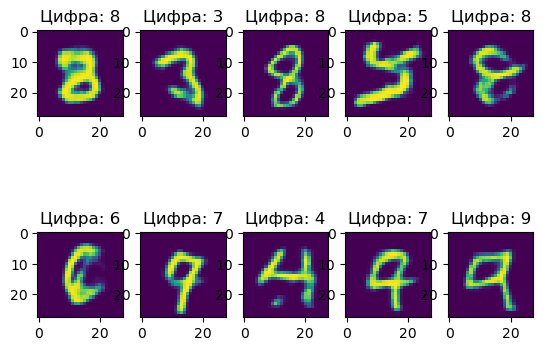

In [103]:
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.title("Цифра: " + str(labels[i].item()))
    plt.imshow(output[i].permute(1, 2, 0).to("cpu").detach().numpy())
plt.show();

Построим разные цифры из одного и того же случайного вектора

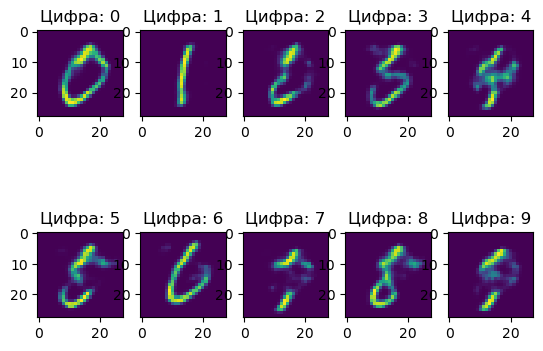

In [99]:
z = torch.Tensor(np.array([np.random.normal(0, 1, vae_latent_dim) for i in range(1)])).to(device)
labels = torch.IntTensor([i for i in range(10)]).to(device).to(torch.int64)
outputs = []
for i in range(10):
    outputs.append(model1.decode(z, torch.IntTensor([i]).to(device).to(torch.int64))) #<скормите z декодеру>
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.title("Цифра: " + str(labels[i].item()))
    plt.imshow(outputs[i][0].permute(1, 2, 0).to("cpu").detach().numpy())
plt.show();

Splendid! Вы великолепны!


### Latent Representations

Давайте посмотрим, как выглядит латентное пространство картинок в CVAE и сравним с картинкой для VAE =)

Опять же, нужно покрасить точки в разные цвета в зависимости от класса.

In [104]:
vectors = torch.FloatTensor([]).to(device)
labels = torch.IntTensor([]).to(device)
for X_batch in test_loader:
    X_batch, label = X_batch
    X_batch, label = X_batch.to(device), label.to(device)
    model1.eval()
    with torch.no_grad():
        vec = model1.reparameterize(*model1.encode(X_batch))
    vectors = torch.cat((vectors, vec))
    labels = torch.cat((labels, label.flatten()))

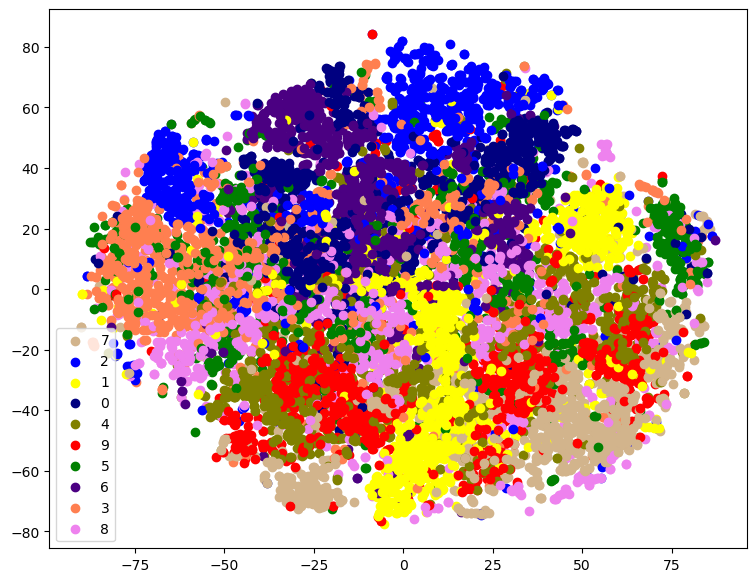

In [105]:
X_embedded = TSNE().fit_transform(vectors.to("cpu"))
colors = ["navy", "yellow", "blue", "coral", "olive", "green", "indigo", "tan", "violet", "red"]
mask = [False for i in range(10)]
plt.figure(figsize=(9, 7))
for i in range(len(labels)):
    if mask[labels[i]]:
        plt.scatter(X_embedded[i][0], X_embedded[i][1], c=colors[labels[i]])
    else:
        mask[labels[i]] = True
        plt.scatter(X_embedded[i][0], X_embedded[i][1], c=colors[labels[i]], label=labels[i].item())
plt.legend()
plt.show();

Что вы думаете насчет этой картинки? Отличается от картинки для VAE?
1) отсутствует явная кластеризация
2) в сравнении с обычным VAE точки латентного пр-ва находяться ближе друг к дургу
3) Из всего вышесказанного можно сделать вывод, что энкодер обучился как-то иначе и скорее всего обучился находить какие-то более общие характеристики картинок

# BONUS 1: Denoising

## Внимание! За бонусы доп. баллы не ставятся, но вы можете сделать их для себя.

У автоэнкодеров, кроме сжатия и генерации изображений, есть другие практические применения. Про одно из них эта бонусная часть задания.

Автоэнкодеры могут быть использованы для избавления от шума на фотографиях (denoising). Для этого их нужно обучить специальным образом: input картинка будет зашумленной, а выдавать автоэнкодер должен будет картинку без шума.
То есть, loss-функция AE останется той же (MSE между реальной картинкой и выданной), а на вход автоэнкодеру будет подаваться зашумленная картинка.

<a href="https://ibb.co/YbRJ1nZ"><img src="https://i.ibb.co/0QD164t/Screen-Shot-2020-06-04-at-4-49-50-PM.png" alt="Screen-Shot-2020-06-04-at-4-49-50-PM" border="0"></a>

Для этого нужно взять ваш любимый датасет (датасет лиц из первой части этого задания или любой другой) и сделать копию этого датасета с шумом.

В питоне шум можно добавить так:

In [ ]:
noise_factor = 0.5
X_noisy = X + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=X.shape)

In [ ]:
<тут ваш код обучения автоэнкодера на зашумленных картинках. Не забудтье разбить на train/test!>

In [ ]:
<тут проверка, как AE убирает щум с тестовых картинок. Надеюсь, все получилось =)>

# BONUS 2: Image Retrieval

## Внимание! За бонусы доп. баллы не ставятся, но вы можете сделать их для себя.

Давайте представим, что весь наш тренировочный датасет -- это большая база данных людей. И вот мы получили картинку лица какого-то человека с уличной камеры наблюдения (у нас это картинка из тестового датасета) и хотим понять, что это за человек. Что нам делать? Правильно -- берем наш VAE, кодируем картинку в латентное представление и ищем среди латентныз представлений лиц нашей базы самые ближайшие!

План:

1. Получаем латентные представления всех лиц тренировочного датасета
2. Обучаем на них LSHForest `(sklearn.neighbors.LSHForest)`, например, с `n_estimators=50`
3. Берем картинку из тестового датасета, с помощью VAE получаем ее латентный вектор
4. Ищем с помощью обученного LSHForest ближайшие из латентных представлений тренировочной базы
5. Находим лица тренировочного датасета, которым соответствуют ближайшие латентные представления, визуализируем!

Немного кода вам в помощь: (feel free to delete everything and write your own)

In [ ]:
codes = <поучите латентные представления картинок из трейна>

In [ ]:
# обучаем LSHForest
from sklearn.neighbors import LSHForest
lshf = LSHForest(n_estimators=50).fit(codes)

In [ ]:
def get_similar(image, n_neighbors=5):
  # функция, которая берет тестовый image и с помощью метода kneighbours у LSHForest ищет ближайшие векторы
  # прогоняет векторы через декодер и получает картинки ближайших людей

  code = <получение латентного представления image>

  (distances,),(idx,) = lshf.kneighbors(code, n_neighbors=n_neighbors)

  return distances, X_train[idx]

In [ ]:
def show_similar(image):

  # функция, которая принимает тестовый image, ищет ближайшие к нему и визуализирует результат

    distances,neighbors = get_similar(image,n_neighbors=11)

    plt.figure(figsize=[8,6])
    plt.subplot(3,4,1)
    plt.imshow(image.cpu().numpy().transpose([1,2,0]))
    plt.title("Original image")

    for i in range(11):
        plt.subplot(3,4,i+2)
        plt.imshow(neighbors[i].cpu().numpy().transpose([1,2,0]))
        plt.title("Dist=%.3f"%distances[i])
    plt.show()

In [ ]:
<тут выведите самые похожие лица к какому-нибудь лицу из тестовой части датасета>